# Attention–cCRE distance-to-TSS analysis

**Purpose.** This notebook annotates the existing `attention_overlap_{eid}.csv` table with TSS-level information from `meta_data_{eid}.csv`, computes cCRE distances relative to the TSS, and summarizes whether high-attention cCREs are mainly promoter-proximal or distal.

**Reviewer-facing question.** The analysis directly addresses whether cCREs overlapping high-attention regions are concentrated near the TSS. It reports the fraction of high-attention cCREs within ±2 kb, ±5 kb, and ±10 kb, and generates distance-distribution plots relative to the TSS.

**Coordinate convention.** Signed distance is strand-aware: positive values indicate downstream of the TSS in the transcriptional direction, and negative values indicate upstream. Absolute distance ignores strand and is used for promoter-proximal classification.

In [99]:
from pathlib import Path

import numpy as np
import pandas as pd

# -----------------------------
# User parameters
# -----------------------------
eid = "E116"

input_overlap_path = Path(f"extra/results/attention_overlap_{eid}.csv")
input_meta_path = Path(f"extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv")
# output_dir = Path("extra/results")
# output_dir.mkdir(parents=True, exist_ok=True)

# annotated_overlap_path = output_dir / f"attention_overlap_{eid}_with_tss.csv"
# summary_path = output_dir / f"attention_cres_tss_distance_summary_{eid}.csv"
# type_summary_path = output_dir / f"attention_cres_tss_distance_by_type_{eid}.csv"

# Distance cutoffs used to define promoter-proximal cCREs.
PROXIMAL_CUTOFFS = (2000, 5000, 10000)

# Distance bins used for a mutually exclusive distance category.
# The last category is >10 kb, not necessarily >20 kb.
DISTANCE_BINS = [0, 2000, 5000, 10000, np.inf]
DISTANCE_LABELS = ["0-2 kb", "2-5 kb", "5-10 kb", "10-20 kb"]

EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}



In [100]:
# ================================
# 0. Imports and plotting style
# ================================
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}




## Note 1 — Input tables

This notebook assumes that `attention_overlap_{eid}.csv` has already been generated by the attention–cCRE overlap script. It does **not** recompute attention weights. It only loads the existing overlap table and the corresponding gene metadata table, then adds TSS coordinates and distance-based summaries.

In the current processed metadata, `start` and `end` correspond to TSS-centered coordinates with nearly 1-bp width, so `start` is used as the TSS coordinate.


In [101]:
def load_input_tables(overlap_path: Path, meta_path: Path):
    """Load the existing attention-cCRE overlap table and the matching gene metadata table."""
    df_overlap = pd.read_csv(overlap_path)
    meta_data = pd.read_csv(meta_path)

    if "gene_name" not in meta_data.columns:
        meta_data["gene_name"] = np.nan

    return df_overlap, meta_data


df_overlap, meta_data = load_input_tables(input_overlap_path, input_meta_path)

print("df_overlap:", df_overlap.shape)
print("meta_data:", meta_data.shape)
df_overlap.head()



df_overlap: (886886, 13)
meta_data: (15865, 24)


,gene_id,chrom,region_start,region_end,region_type,dim,cres_id,cres_type,cres_start,cres_end,overlap_start,overlap_end,overlap_length
0,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243756,"pELS,CTCF-bound",73718642.0,73718964.0,73718642.0,73718964.0,322
1,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E1886218,"pELS,CTCF-bound",73718148.0,73718449.0,73718148.0,73718449.0,301
2,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243757,"pELS,CTCF-bound",73719322.0,73719670.0,73719322.0,73719537.0,215
3,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E3243739,dELS,73699504.0,73699782.0,73699504.0,73699782.0,278
4,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E1886208,dELS,73699786.0,73699980.0,73699786.0,73699980.0,194


In [102]:
CRE_TYPE_ORDER = [
    "pELS,CTCF-bound",
    "pELS",
    "dELS",
    "Other",
    "dELS,CTCF-bound",
]

def map_cres_type(raw_type):
    """Map raw cCRE annotations to the five classes used in reviewer-facing plots."""
    if pd.isna(raw_type):
        return "Other"

    raw_type = str(raw_type).strip()

    cres_type_map = {
        "pELS_CTCF-bound": "pELS,CTCF-bound",
        "pELS,CTCF-bound": "pELS,CTCF-bound",
        "pELS": "pELS",

        "dELS_CTCF-bound": "dELS,CTCF-bound",
        "dELS,CTCF-bound": "dELS,CTCF-bound",
        "dELS": "dELS",
    }

    return cres_type_map.get(raw_type, "Other")


def apply_cres_type_map(df: pd.DataFrame) -> pd.DataFrame:
    """Add raw cCRE type and replace cres_type with a five-class mapped label."""
    df = df.copy()
    df["cres_type_raw"] = df["cres_type"]
    df["cres_type"] = df["cres_type_raw"].map(map_cres_type)
    df["cres_type"] = pd.Categorical(
        df["cres_type"],
        categories=CRE_TYPE_ORDER,
        ordered=True,
    )
    return df


df_overlap = apply_cres_type_map(df_overlap)
df_overlap 

,gene_id,chrom,region_start,region_end,region_type,dim,cres_id,cres_type,cres_start,cres_end,overlap_start,overlap_end,overlap_length,cres_type_raw
0,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243756,"pELS,CTCF-bound",73718642.0,73718964.0,73718642.0,73718964.0,322,"pELS,CTCF-bound"
1,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E1886218,"pELS,CTCF-bound",73718148.0,73718449.0,73718148.0,73718449.0,301,"pELS,CTCF-bound"
2,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243757,"pELS,CTCF-bound",73719322.0,73719670.0,73719322.0,73719537.0,215,"pELS,CTCF-bound"
3,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E3243739,dELS,73699504.0,73699782.0,73699504.0,73699782.0,278,dELS
4,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E1886208,dELS,73699786.0,73699980.0,73699786.0,73699980.0,194,dELS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886881,ENSG00000172955,chr4,100120903.0,100160403.0,non_attention,1.0,EH38E3596636,dELS,100121322.0,100121628.0,100121322.0,100121628.0,306,dELS
886882,ENSG00000172955,chr4,100120903.0,100160403.0,non_attention,1.0,EH38E3596644,dELS,100151434.0,100151703.0,100151434.0,100151703.0,269,dELS
886883,ENSG00000172955,chr4,100120903.0,100160403.0,non_attention,1.0,EH38E2314979,dELS,100152916.0,100153071.0,100152916.0,100153071.0,155,dELS
886884,ENSG00000172955,chr4,100120903.0,100160403.0,non_attention,1.0,EH38E2314972,dELS,100129197.0,100129536.0,100129197.0,100129536.0,339,dELS


## Note 2 — TSS annotation and strand-aware distance

For each `gene_id`, the notebook keeps one metadata record and adds:

- `tss`: TSS coordinate, taken from `meta_data['start']`;
- `gene_strand`: transcriptional strand;
- `gene_chrom`: chromosome from the gene metadata;
- signed distances from region/cCRE/overlap midpoints to the TSS;
- absolute distances used for promoter-proximal classification.

The signed distance is defined as:

- positive for downstream positions relative to the transcriptional direction;
- negative for upstream positions relative to the transcriptional direction.

This avoids mixing positive- and negative-strand genes when visualizing cCRE positions relative to TSS.

In [103]:
def signed_distance_to_tss(pos, tss, strand):
    """
    Strand-aware signed distance to TSS.

    Positive value: downstream of TSS in transcriptional direction.
    Negative value: upstream of TSS in transcriptional direction.
    """
    if pd.isna(pos) or pd.isna(tss) or pd.isna(strand):
        return np.nan

    pos = float(pos)
    tss = float(tss)

    if strand == "+":
        return pos - tss
    if strand == "-":
        return tss - pos
    return np.nan


def annotate_tss_and_distances(
    df_overlap: pd.DataFrame,
    meta_data: pd.DataFrame,
    proximal_cutoffs=PROXIMAL_CUTOFFS,
) -> pd.DataFrame:
    """Add TSS information and cCRE/attention-region distances to an overlap table."""
    tss_info = (
        meta_data[["gene_id", "chrom", "start", "end", "strand", "gene_name"]]
        .drop_duplicates(subset=["gene_id"])
        .rename(
            columns={
                "chrom": "gene_chrom",
                "start": "tss",
                "end": "tss_end",
                "strand": "gene_strand",
            }
        )
    )

    df = df_overlap.merge(tss_info, on="gene_id", how="left")

    # Midpoints. These remain NaN when the original intervals are missing.
    df["region_mid"] = (df["region_start"] + df["region_end"]) / 2
    df["cres_mid"] = (df["cres_start"] + df["cres_end"]) / 2
    df["overlap_mid"] = (df["overlap_start"] + df["overlap_end"]) / 2

    # Signed strand-aware distances.
    for prefix, pos_col in {
        "region": "region_mid",
        "cres": "cres_mid",
        "overlap": "overlap_mid",
        "cres_start": "cres_start",
        "cres_end": "cres_end",
    }.items():
        df[f"{prefix}_distance_to_tss"] = df.apply(
            lambda row: signed_distance_to_tss(row[pos_col], row["tss"], row["gene_strand"]),
            axis=1,
        )

    # Absolute distances.
    for prefix in ["region", "cres", "overlap"]:
        df[f"{prefix}_abs_distance_to_tss"] = df[f"{prefix}_distance_to_tss"].abs()

    # Relative cCRE interval boundaries, ordered from upstream to downstream in signed coordinate space.
    df["cres_rel_start"] = df[["cres_start_distance_to_tss", "cres_end_distance_to_tss"]].min(axis=1)
    df["cres_rel_end"] = df[["cres_start_distance_to_tss", "cres_end_distance_to_tss"]].max(axis=1)

    # Promoter-proximal flags.
    for cutoff in proximal_cutoffs:
        df[f"is_promoter_proximal_{cutoff // 1000}kb"] = df["cres_abs_distance_to_tss"] <= cutoff

    # Mutually exclusive cCRE distance category.
    df["cres_tss_distance_bin"] = pd.cut(
        df["cres_abs_distance_to_tss"],
        bins=DISTANCE_BINS,
        labels=DISTANCE_LABELS,
        include_lowest=True,
        right=True,
    )

    return df


df_annot = annotate_tss_and_distances(df_overlap, meta_data)

print("Annotated table:", df_annot.shape)

# df_annot.to_csv(annotated_overlap_path, index=False)
# print(f"[Saved] {annotated_overlap_path}")

df_annot.head()


Annotated table: (886886, 36)


,gene_id,chrom,region_start,region_end,region_type,dim,cres_id,cres_type,cres_start,cres_end,...,cres_end_distance_to_tss,region_abs_distance_to_tss,cres_abs_distance_to_tss,overlap_abs_distance_to_tss,cres_rel_start,cres_rel_end,is_promoter_proximal_2kb,is_promoter_proximal_5kb,is_promoter_proximal_10kb,cres_tss_distance_bin
0,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243756,"pELS,CTCF-bound",73718642.0,73718964.0,...,1427.0,1250.0,1266.0,1266.0,1105.0,1427.0,True,True,True,0-2 kb
1,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E1886218,"pELS,CTCF-bound",73718148.0,73718449.0,...,912.0,1250.0,761.5,761.5,611.0,912.0,True,True,True,0-2 kb
2,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243757,"pELS,CTCF-bound",73719322.0,73719670.0,...,2133.0,1250.0,1959.0,1892.5,1785.0,2133.0,True,True,True,0-2 kb
3,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E3243739,dELS,73699504.0,73699782.0,...,-17755.0,9750.0,17894.0,17894.0,-18033.0,-17755.0,False,False,False,10-20 kb
4,ENSG00000132470,chr17,73697537.0,73718037.0,non_attention,0.0,EH38E1886208,dELS,73699786.0,73699980.0,...,-17557.0,9750.0,17654.0,17654.0,-17751.0,-17557.0,False,False,False,10-20 kb


## Note 3 — Deduplication rule

A single cCRE can overlap more than one attention interval or appear multiple times across rows. For reviewer-facing summaries, the notebook deduplicates by:

`gene_id`, `dim`, `cres_id`, `cres_start`, `cres_end`

This preserves the two attention dimensions separately while avoiding inflation from fragmented overlap intervals. If the final manuscript reports gene-level rather than dimension-level statistics, change the deduplication key by removing `dim`.

In [104]:
def get_attention_cres(df: pd.DataFrame, keep_dim: bool = True) -> pd.DataFrame:
    """Return unique high-attention-overlapping cCREs."""
    df_att = df[(df["region_type"] == "attention") & df["cres_id"].notna()].copy()

    subset = ["gene_id", "cres_id", "cres_start", "cres_end"]
    if keep_dim and "dim" in df_att.columns:
        subset.insert(1, "dim")

    return df_att.drop_duplicates(subset=subset).reset_index(drop=True)


df_att_unique = get_attention_cres(df_annot, keep_dim=True)

print("Unique high-attention cCREs:", df_att_unique.shape)
df_att_unique[[
    "gene_id", "gene_name", "dim", "cres_id", "cres_type",
    "tss", "gene_strand", "cres_mid", "cres_distance_to_tss",
    "cres_abs_distance_to_tss", "cres_tss_distance_bin",
]].head(100)

Unique high-attention cCREs: (38599, 36)


,gene_id,gene_name,dim,cres_id,cres_type,tss,gene_strand,cres_mid,cres_distance_to_tss,cres_abs_distance_to_tss,cres_tss_distance_bin
0,ENSG00000132470,ITGB4,0.0,EH38E3243756,"pELS,CTCF-bound",73717537,+,73718803.0,1266.0,1266.0,0-2 kb
1,ENSG00000132470,ITGB4,0.0,EH38E1886218,"pELS,CTCF-bound",73717537,+,73718298.5,761.5,761.5,0-2 kb
2,ENSG00000132470,ITGB4,0.0,EH38E3243757,"pELS,CTCF-bound",73717537,+,73719496.0,1959.0,1959.0,0-2 kb
3,ENSG00000197446,CYP2F1,0.0,EH38E1954555,pELS,41620335,+,41622135.5,1800.5,1800.5,0-2 kb
4,ENSG00000105576,TNPO2,1.0,EH38E3291157,Other,12834746,-,12833008.0,1738.0,1738.0,0-2 kb
...,...,...,...,...,...,...,...,...,...,...,...
95,ENSG00000183019,MCEMP1,0.0,EH38E3287665,"pELS,CTCF-bound",7741941,+,7744035.5,2094.5,2094.5,2-5 kb
96,ENSG00000183019,MCEMP1,1.0,EH38E3287658,pELS,7741941,+,7735494.5,-6446.5,6446.5,5-10 kb
97,ENSG00000183019,MCEMP1,1.0,EH38E3287659,pELS,7741941,+,7735870.0,-6071.0,6071.0,5-10 kb
98,ENSG00000184216,IRAK1,0.0,EH38E3949359,dELS,153285353,-,153288487.5,-3134.5,3134.5,2-5 kb


In [115]:
df_att_unique

,gene_id,chrom,region_start,region_end,region_type,dim,cres_id,cres_type,cres_start,cres_end,...,cres_end_distance_to_tss,region_abs_distance_to_tss,cres_abs_distance_to_tss,overlap_abs_distance_to_tss,cres_rel_start,cres_rel_end,is_promoter_proximal_2kb,is_promoter_proximal_5kb,is_promoter_proximal_10kb,cres_tss_distance_bin
0,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243756,"pELS,CTCF-bound",73718642.0,73718964.0,...,1427.0,1250.0,1266.0,1266.0,1105.0,1427.0,True,True,True,0-2 kb
1,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E1886218,"pELS,CTCF-bound",73718148.0,73718449.0,...,912.0,1250.0,761.5,761.5,611.0,912.0,True,True,True,0-2 kb
2,ENSG00000132470,chr17,73718037.0,73719537.0,attention,0.0,EH38E3243757,"pELS,CTCF-bound",73719322.0,73719670.0,...,2133.0,1250.0,1959.0,1892.5,1785.0,2133.0,True,True,True,0-2 kb
3,ENSG00000197446,chr19,41620835.0,41622335.0,attention,0.0,EH38E1954555,pELS,41622011.0,41622260.0,...,1925.0,1250.0,1800.5,1800.5,1676.0,1925.0,True,True,True,0-2 kb
4,ENSG00000105576,chr19,12832746.0,12833246.0,attention,1.0,EH38E3291157,Other,12832835.0,12833181.0,...,1565.0,1750.0,1738.0,1738.0,1565.0,1911.0,True,True,True,0-2 kb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38594,ENSG00000163166,chr2,128285565.0,128287065.0,attention,0.0,EH38E2031354,pELS,128285772.0,128286061.0,...,-1996.0,2250.0,1851.5,1851.5,-1996.0,-1707.0,True,True,True,0-2 kb
38595,ENSG00000163166,chr2,128285565.0,128287065.0,attention,0.0,EH38E3370403,"pELS,CTCF-bound",128285413.0,128285649.0,...,-1584.0,2250.0,1466.0,1542.0,-1584.0,-1348.0,True,True,True,0-2 kb
38596,ENSG00000163166,chr2,128281565.0,128282565.0,attention,1.0,EH38E3370397,pELS,128282427.0,128282677.0,...,1388.0,2000.0,1513.0,1569.0,1388.0,1638.0,True,True,True,0-2 kb
38597,ENSG00000164306,chr4,185573890.0,185574890.0,attention,1.0,EH38E3619119,dELS,185574825.0,185575173.0,...,4283.0,3500.0,4109.0,3967.5,3935.0,4283.0,False,True,True,2-5 kb


## Note 4 — Promoter-proximal fraction

The table below reports the fraction of high-attention-overlapping cCREs located within ±2 kb, ±5 kb, and ±10 kb of the TSS. These three cutoffs provide a direct quantitative response to the reviewer’s request to report how much of the high-attention cCRE signal is promoter-proximal.

In [105]:
def summarize_promoter_proximal_fraction(
    df_att_unique: pd.DataFrame,
    cutoffs=PROXIMAL_CUTOFFS,
) -> pd.DataFrame:
    """Summarize proximal/distal fractions among high-attention cCREs."""
    n_total = len(df_att_unique)
    rows = []

    for cutoff in cutoffs:
        col = f"is_promoter_proximal_{cutoff // 1000}kb"
        n_proximal = int(df_att_unique[col].sum()) if n_total > 0 else 0
        frac_proximal = n_proximal / n_total if n_total > 0 else np.nan

        rows.append(
            {
                "cutoff_bp": cutoff,
                "cutoff": f"±{cutoff // 1000} kb",
                "n_attention_cres": n_total,
                "n_promoter_proximal": n_proximal,
                "fraction_promoter_proximal": frac_proximal,
                "n_distal": n_total - n_proximal,
                "fraction_distal": 1 - frac_proximal if n_total > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)


summary = summarize_promoter_proximal_fraction(df_att_unique)
# summary.to_csv(summary_path, index=False)
# print(f"[Saved] {summary_path}")
summary

,cutoff_bp,cutoff,n_attention_cres,n_promoter_proximal,fraction_promoter_proximal,n_distal,fraction_distal
0,2000,±2 kb,38599,20597,0.533615,18002,0.466385
1,5000,±5 kb,38599,31235,0.809218,7364,0.190782
2,10000,±10 kb,38599,34460,0.892769,4139,0.107231


## Note 5 — Distance-bin and cCRE-type summaries

The following summaries are useful for supplementing the main proximal-fraction result. They show whether the high-attention cCREs are dominated by promoter-like annotations near the TSS or whether distal enhancer-like annotations remain represented beyond promoter-proximal windows.

In [106]:
# Mutually exclusive distance-bin summary.
distance_bin_summary = (
    df_att_unique
    .groupby("cres_tss_distance_bin", observed=False)
    .size()
    .reset_index(name="n_attention_cres")
)
distance_bin_summary["fraction"] = (
    distance_bin_summary["n_attention_cres"] / distance_bin_summary["n_attention_cres"].sum()
)

# cCRE type by distance-bin summary.
type_distance_summary = (
    df_att_unique
    .groupby(["cres_type", "cres_tss_distance_bin"], observed=False)
    .size()
    .reset_index(name="n_attention_cres")
)
type_distance_summary["fraction_within_type"] = (
    type_distance_summary["n_attention_cres"]
    / type_distance_summary.groupby("cres_tss_distance_bin")["n_attention_cres"].transform("sum")
)

# type_distance_summary.to_csv(type_summary_path, index=False)
# print(f"[Saved] {type_summary_path}")

print("Distance-bin summary:")
display(distance_bin_summary)

print("cCRE type × distance-bin summary:")
display(type_distance_summary.head(20))

Distance-bin summary:


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32149/1642277830.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  / type_distance_summary.groupby("cres_tss_distance_bin")["n_attention_cres"].transform("sum")


,cres_tss_distance_bin,n_attention_cres,fraction
0,0-2 kb,20597,0.533615
1,2-5 kb,10638,0.275603
2,5-10 kb,3225,0.083551
3,10-20 kb,4139,0.107231


cCRE type × distance-bin summary:


,cres_type,cres_tss_distance_bin,n_attention_cres,fraction_within_type
0,"pELS,CTCF-bound",0-2 kb,10489,0.509249
1,"pELS,CTCF-bound",2-5 kb,1710,0.160745
2,"pELS,CTCF-bound",5-10 kb,614,0.190388
3,"pELS,CTCF-bound",10-20 kb,895,0.216236
4,pELS,0-2 kb,6583,0.319610
5,pELS,2-5 kb,1545,0.145234
6,pELS,5-10 kb,281,0.087132
7,pELS,10-20 kb,382,0.092293
8,dELS,0-2 kb,99,0.004807
9,dELS,2-5 kb,3913,0.367832


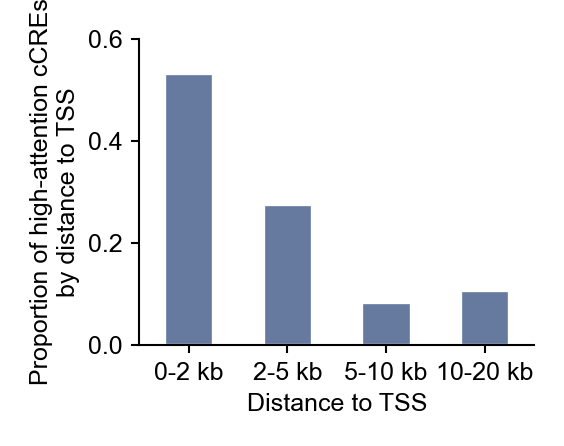

In [107]:
fig, ax = plt.subplots(figsize=(5/2.54, 4/2.54))

sns.barplot(
    data=distance_bin_summary,
    x="cres_tss_distance_bin",
    y="fraction",
    color="#5B78A8",
    width=0.5,
)

ax.set_xlabel("Distance to TSS", labelpad=2)

ax.set_ylabel("Proportion of high-attention cCREs\nby distance to TSS")

ax.set_ylim(0, 0.6)
ax.set_yticks(np.arange(0, 0.61, 0.2))


ax.tick_params(axis="x", labelrotation=0)
ax.tick_params(axis="both",)

plt.tight_layout()
plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/cres_distribution_distance_{eid}.pdf',format='pdf', bbox_inches="tight")
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32149/3228451198.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(plot_df["cres_tss_distance_bin"]):


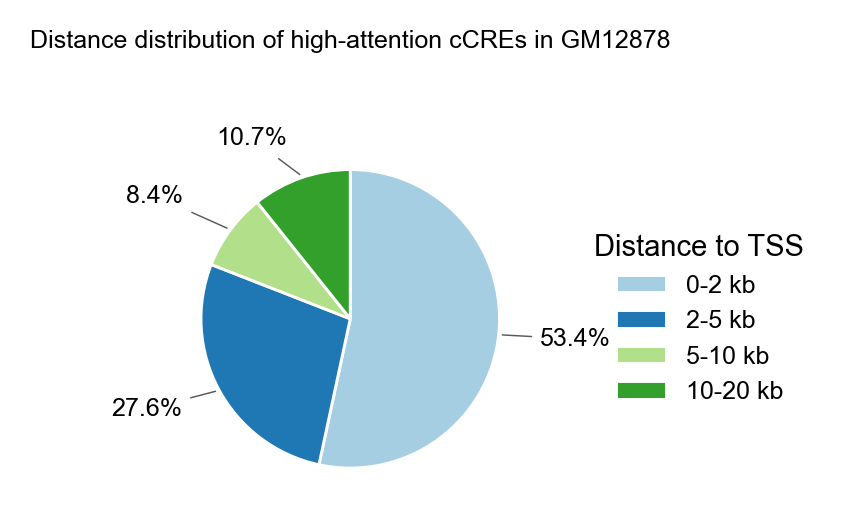

In [108]:
# import numpy as np
# import matplotlib.pyplot as plt

# ============================================================
# Plot pie chart for cCRE distance distribution
# ============================================================

plot_df = distance_bin_summary.copy()

# 保持原始 distance bin 顺序
# 如果 cres_tss_distance_bin 已经是 categorical，则按 categorical 顺序排序
if pd.api.types.is_categorical_dtype(plot_df["cres_tss_distance_bin"]):
    plot_df = plot_df.sort_values("cres_tss_distance_bin")
else:
    plot_df = plot_df.sort_values("cres_tss_distance_bin")

values = plot_df["fraction"].to_numpy()
legend_labels = plot_df["cres_tss_distance_bin"].astype(str).to_list()

# 如果 fraction 已经是比例，总和一般为 1
# 为避免浮点误差或过滤后不完全为 1，这里重新归一化用于画饼图
values = values / values.sum()

colors = [
    "#A6CEE3",
    "#1F78B4",
    "#B2DF8A",
    "#33A02C",
    "#FB9A99",
    "#E31A1C",
    "#FDBF6F",
    "#FF7F00",
    "#CAB2D6",
    "#6A3D9A",
]

fig, ax = plt.subplots(figsize=(6.5 / 2.54, 4.8 / 2.54))

wedges, _ = ax.pie(
    values,
    labels=None,
    colors=colors[:len(values)],
    startangle=90,
    counterclock=False,
    radius=0.82,
    wedgeprops={
        "linewidth": 0.7,
        "edgecolor": "white",
    },
)

# ------------------------------------------------------------
# Percentage labels outside sectors
# ------------------------------------------------------------

manual_offsets = {
    # 根据你的 distance bin 名称可以继续手动微调
    # 示例：
    # "0-1 kb": (0.00, 0.00),
    # "1-5 kb": (-0.04, 0.03),
    # "5-10 kb": (0.06, 0.05),
    # ">10 kb": (0.10, 0.10),
}

for wedge, value, label_name in zip(wedges, values, legend_labels):
    pct = 100 * value
    label = f"{pct:.1f}%"

    angle = (wedge.theta1 + wedge.theta2) / 2.0
    angle_rad = np.deg2rad(angle)

    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    # 大扇区离饼图近，小扇区远一些
    if pct >= 10:
        r_text = 1.05
    elif pct >= 3:
        r_text = 1.14
    else:
        r_text = 1.25

    dx, dy = manual_offsets.get(label_name, (0.0, 0.0))

    x_text = r_text * x + dx
    y_text = r_text * y + dy

    ha = "left" if x_text >= 0 else "right"

    ax.annotate(
        label,
        xy=(0.84 * x, 0.84 * y),
        xytext=(x_text, y_text),
        ha=ha,
        va="center",
        fontsize=6,
        arrowprops={
            "arrowstyle": "-",
            "lw": 0.35,
            "color": "0.35",
            "shrinkA": 0,
            "shrinkB": 0,
        },
    )

# ------------------------------------------------------------
# Title and legend
# ------------------------------------------------------------

eid_label_map = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

eid_label = eid_label_map.get(eid, eid)

ax.set_title(
    f"Distance distribution of high-attention cCREs in {eid_label}",
    pad=6,
    y=1.25,
)

ax.legend(
    wedges,
    legend_labels,
    title="Distance to TSS",
    frameon=False,
    fontsize=6,
    title_fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.08, 0.5),
    borderaxespad=0,
)

ax.axis("equal")

plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer1/figures/cres_distribution_distance_{eid}.pdf",
    format="pdf",
    bbox_inches="tight",
)

# plt.savefig(
#     f"benchmarks/revised_v2/reviewer1/figures/cres_distribution_distance_{eid}.eps",
#     format="eps",
#     bbox_inches="tight",
# )

plt.show()

## Note 6 — Plots for the revision

Recommended figure panels:

1. **Distance distribution:** signed cCRE distance to TSS in kb. This shows whether high-attention cCREs cluster around the TSS or extend into distal regions.
2. **cCRE type-specific distance distribution:** same distance axis, stratified by cCRE type.
3. **Promoter-proximal fraction:** fraction of high-attention cCREs within ±2 kb, ±5 kb, and ±10 kb.
4. **Distance-bin composition:** mutually exclusive distance bins, useful if the reviewer asks for exact proportions rather than cumulative cutoffs.

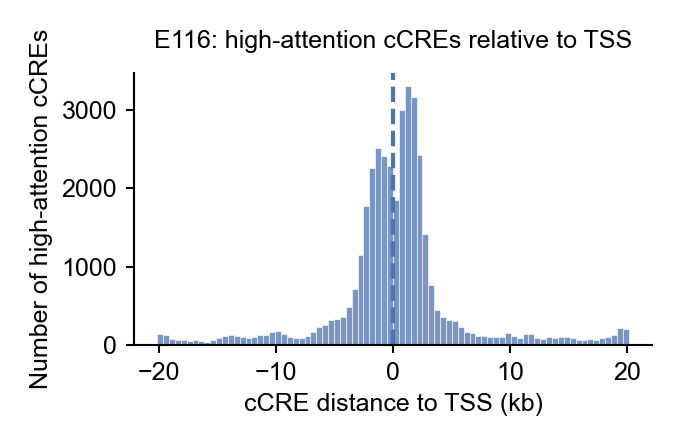

In [109]:
# Prepare plotting table.
df_plot = df_att_unique.copy()
df_plot["cres_distance_to_tss_kb"] = df_plot["cres_distance_to_tss"] / 1000

# Optional: restrict x-axis to the input window if needed.
# df_plot = df_plot[df_plot["cres_abs_distance_to_tss"] <= 20000].copy()

# fig_path = output_dir / f"attention_cres_distance_to_tss_{eid}.pdf"

plt.figure(figsize=(6/2.54, 4/2.54))
sns.histplot(
    data=df_plot,
    x="cres_distance_to_tss_kb",
    bins=80,
    kde=False,
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("cCRE distance to TSS (kb)")
plt.ylabel("Number of high-attention cCREs")
plt.title(f"{eid}: high-attention cCREs relative to TSS")
plt.tight_layout()
# plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

# print(f"[Saved] {fig_path}")

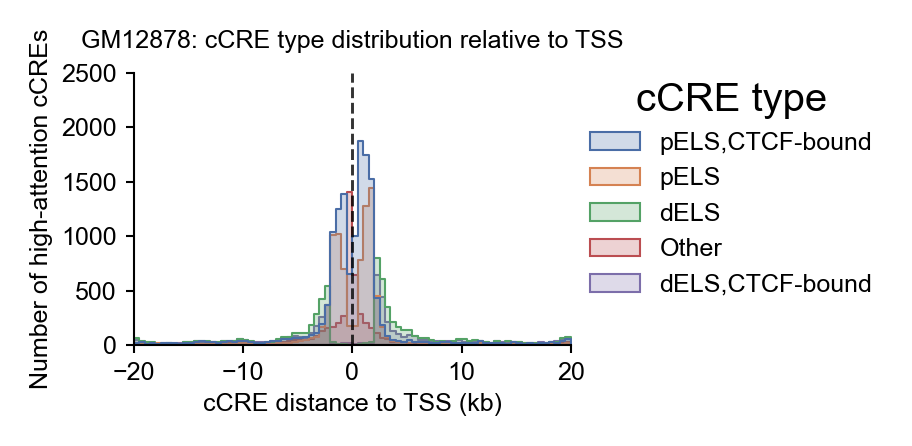

In [110]:
# fig_path = output_dir / f"attention_cres_type_distance_to_tss_{eid}.pdf"

# 只使用这 5 类，并固定显示顺序
CRE_TYPE_ORDER = [
    "pELS,CTCF-bound",
    "pELS",
    "dELS",
    "Other",
    "dELS,CTCF-bound",
]
CRE_TYPE_COLORS = {
    "pELS,CTCF-bound": "#4A6DA6",
    "pELS": "#D58252",
    "dELS": "#54A266",
    "Other": "#BB4D51",
    "dELS,CTCF-bound": "#7C6EAA",
}

df_plot_use = df_plot.copy()
df_plot_use = df_plot_use[df_plot_use["cres_type"].isin(CRE_TYPE_ORDER)].copy()
df_plot_use["cres_type"] = pd.Categorical(
    df_plot_use["cres_type"],
    categories=CRE_TYPE_ORDER,
    ordered=True,
)

# 去除缺失距离，避免绘图警告
df_plot_use = df_plot_use.dropna(subset=["cres_distance_to_tss_kb", "cres_type"])

# 固定 bin，保证每次绘图范围和分辨率一致
bins = np.linspace(-20, 20, 81)

fig, ax = plt.subplots(figsize=(8/2.54, 4/2.54))

sns.histplot(
    data=df_plot_use,
    x="cres_distance_to_tss_kb",
    hue="cres_type",
    hue_order=CRE_TYPE_ORDER,
    palette=CRE_TYPE_COLORS,
    bins=bins,
    element="step",
    fill=True,
    stat="count",
    common_norm=False,
    linewidth=0.5,
    ax=ax,
)

# TSS 位置
ax.axvline(0, linestyle="--", linewidth=0.7, color="black", alpha=0.8)

# 坐标轴与标题
ax.set_xlim(-20, 20)
ax.set_ylim(0,2500)
ax.set_xlabel("cCRE distance to TSS (kb)")
ax.set_ylabel("Number of high-attention cCREs")
ax.set_title(f"{EIDS_TO_CELLTYPES[eid]}: cCRE type distribution relative to TSS")

# 优化图形边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 不要重新调用 plt.legend()，否则会覆盖 seaborn 自动生成的 legend
legend = ax.get_legend()
if legend is not None:
    sns.move_legend(
        ax,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        title="cCRE type",
        frameon=False,
        borderaxespad=0,
    )
    

plt.tight_layout()
plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/cres_distribution_{eid}.pdf',format='pdf', bbox_inches="tight")
plt.show()

# print(f"[Saved] {fig_path}")

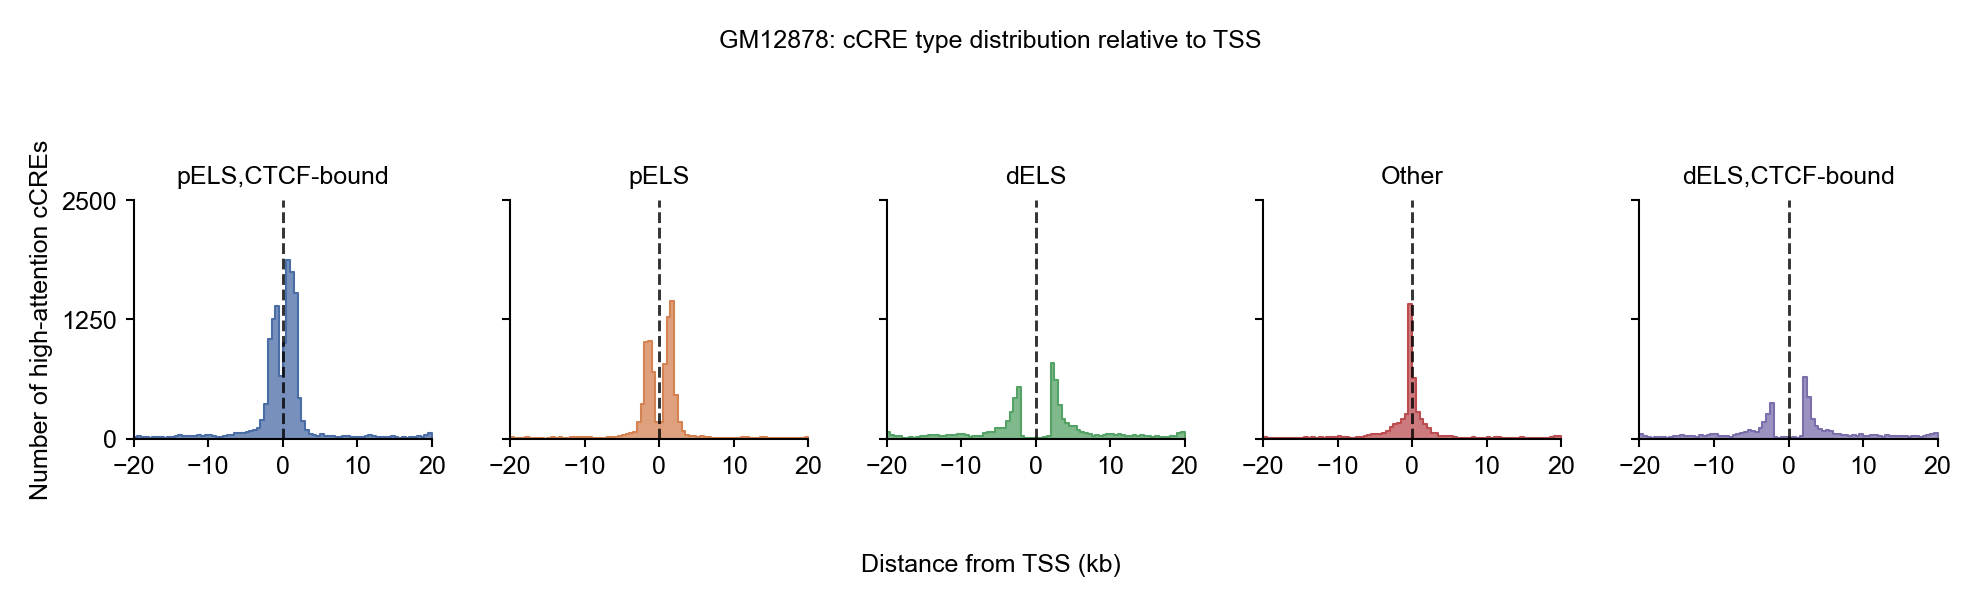

In [111]:
# ============================================================
# Plot each cCRE type separately as 1 x 5 panels
# ============================================================

# 只使用这 5 类，并固定显示顺序
CRE_TYPE_ORDER = [
    "pELS,CTCF-bound",
    "pELS",
    "dELS",
    "Other",
    "dELS,CTCF-bound",
]

CRE_TYPE_COLORS = {
    "pELS,CTCF-bound": "#4A6DA6",
    "pELS": "#D58252",
    "dELS": "#54A266",
    "Other": "#BB4D51",
    "dELS,CTCF-bound": "#7C6EAA",
}

df_plot_use = df_plot.copy()

df_plot_use = df_plot_use[
    df_plot_use["cres_type"].isin(CRE_TYPE_ORDER)
].copy()

df_plot_use["cres_type"] = pd.Categorical(
    df_plot_use["cres_type"],
    categories=CRE_TYPE_ORDER,
    ordered=True,
)

# 去除缺失距离，避免绘图警告
df_plot_use = df_plot_use.dropna(
    subset=["cres_distance_to_tss_kb", "cres_type"]
).copy()

# 保留 -20 kb 到 +20 kb
df_plot_use = df_plot_use[
    (df_plot_use["cres_distance_to_tss_kb"] >= -20)
    & (df_plot_use["cres_distance_to_tss_kb"] <= 20)
].copy()

# 固定 bin，保证每次绘图范围和分辨率一致
bins = np.linspace(-20, 20, 81)

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    len(CRE_TYPE_ORDER),
    figsize=(17 / 2.54, 4.5 / 2.54),
    sharex=True,
    sharey=True,
)

for ax, cre_type in zip(axes, CRE_TYPE_ORDER):
    sub = df_plot_use[df_plot_use["cres_type"] == cre_type].copy()

    sns.histplot(
        data=sub,
        x="cres_distance_to_tss_kb",
        bins=bins,
        element="step",
        fill=True,
        stat="count",
        color=CRE_TYPE_COLORS[cre_type],
        linewidth=0.5,
        ax=ax,
    )

    # TSS 位置
    ax.axvline(
        0,
        linestyle="--",
        linewidth=0.7,
        color="black",
        alpha=0.8,
    )

    ax.set_xlim(-20, 20)
    ax.set_xticks([-20, -10, 0, 10, 20])
    ax.set_title(cre_type, pad=4)
    ax.set_ylim(0,2500)
    ax.set_yticks(np.arange(0, 2501, 1250))

    ax.set_xlabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# 统一坐标轴标签
axes[0].set_ylabel("Number of high-attention cCREs")
for ax in axes[1:]:
    ax.set_ylabel("")

fig.supxlabel("Distance from TSS (kb)", y=0.02)

fig.suptitle(
    f"{EIDS_TO_CELLTYPES[eid]}: cCRE type distribution relative to TSS",
    y=1.05,
)

plt.tight_layout()

plt.savefig(
    f"benchmarks/revised_v2/reviewer1/figures/cres_distribution_by_type_{eid}.pdf",
    format="pdf",
    bbox_inches="tight",
)

# plt.savefig(
#     f"benchmarks/revised_v2/reviewer1/figures/cres_distribution_by_type_{eid}.eps",
#     format="eps",
#     bbox_inches="tight",
# )

plt.show()

## Note 7 — Distal cCRE analysis beyond 5 kbp

This section analyzes only high-attention-overlapping cCREs whose midpoint is located more than 5 kbp away from the TSS, i.e. `cres_abs_distance_to_tss > 5000`.

This is useful for separating genuinely promoter-distal signals from promoter-proximal cCREs. If most high-attention cCREs are removed by this filter, the result indicates that the attention-cCRE overlap is largely promoter-proximal. If a substantial number remain beyond 5 kbp, their distance distribution and cCRE-type composition provide direct evidence for distal cis-regulatory contribution.

In [112]:
# Distal high-attention cCREs beyond 5 kbp from TSS.
DISTAL_CUTOFF_BP = 5000

# Keep only high-attention-overlapping cCREs with midpoint distance > 5 kbp from TSS.
df_distal_5kb = df_att_unique[
    df_att_unique["cres_abs_distance_to_tss"] > DISTAL_CUTOFF_BP
].copy()

# Convert to kb for plotting.
df_distal_5kb["cres_distance_to_tss_kb"] = df_distal_5kb["cres_distance_to_tss"] / 1000
df_distal_5kb["cres_abs_distance_to_tss_kb"] = df_distal_5kb["cres_abs_distance_to_tss"] / 1000

# Save distal-only table.
# distal_table_path = output_dir / f"attention_cres_distal_gt5kb_{eid}.csv"
# df_distal_5kb.to_csv(distal_table_path, index=False)

# Summary: total distal cCREs and fraction among all high-attention cCREs.
distal_summary = pd.DataFrame({
    "cutoff": [">5kb"],
    "n_attention_cres_total": [len(df_att_unique)],
    "n_attention_cres_distal_gt5kb": [len(df_distal_5kb)],
    "fraction_distal_gt5kb": [len(df_distal_5kb) / len(df_att_unique) if len(df_att_unique) > 0 else np.nan],
})

# distal_summary_path = output_dir / f"attention_cres_distal_gt5kb_summary_{eid}.csv"
# distal_summary.to_csv(distal_summary_path, index=False)

# Summary by cCRE type.
distal_type_summary = (
    df_distal_5kb
    .groupby("cres_type", dropna=False)
    .size()
    .reset_index(name="n_distal_gt5kb")
    .sort_values("n_distal_gt5kb", ascending=False)
)

distal_type_summary["fraction_distal_gt5kb"] = (
    distal_type_summary["n_distal_gt5kb"] / distal_type_summary["n_distal_gt5kb"].sum()
    if len(distal_type_summary) > 0 else np.nan
)

display(distal_summary)
display(distal_type_summary.head(20))

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32149/2689531177.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_distal_5kb


,cutoff,n_attention_cres_total,n_attention_cres_distal_gt5kb,fraction_distal_gt5kb
0,>5kb,38599,7364,0.190782


,cres_type,n_distal_gt5kb,fraction_distal_gt5kb
2,dELS,2327,0.315997
4,"dELS,CTCF-bound",2072,0.281369
0,"pELS,CTCF-bound",1509,0.204916
3,Other,793,0.107686
1,pELS,663,0.090033


[Text(0, 0, ''), Text(1, 0, ''), Text(2, 0, ''), Text(3, 0, ''), Text(4, 0, '')]


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_32149/928061416.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


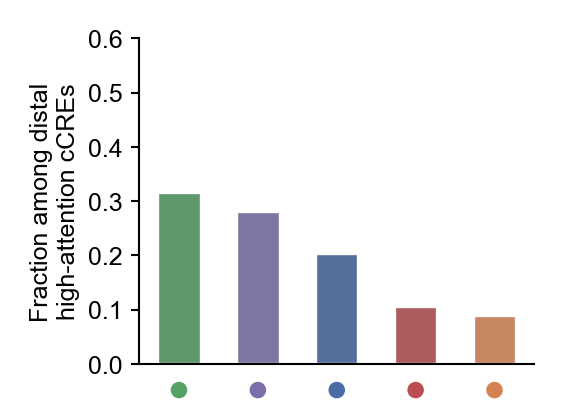

In [113]:
# Plot 2: distal cCRE type composition beyond 5 kbp.
# fig_path = output_dir / f"attention_cres_distal_gt5kb_type_fraction_{eid}.pdf"

CRE_TYPE_COLORS = {
    "pELS,CTCF-bound": "#4A6DA6",
    "pELS": "#D58252",
    "dELS": "#54A266",
    "Other": "#BB4D51",
    "dELS,CTCF-bound": "#7C6EAA",
}

plot_type = distal_type_summary.copy()

order = [
    "pELS,CTCF-bound",
    "pELS",
    "dELS",
    "Other",
    "dELS,CTCF-bound",
]

order = distal_type_summary['cres_type'].tolist()


plot_type = plot_type[plot_type["cres_type"].isin(order)].copy()
plot_type["cres_type"] = pd.Categorical(
    plot_type["cres_type"],
    categories=order,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(5/2.54, 4/2.54))

sns.barplot(
    data=plot_type,
    x="cres_type",
    y="fraction_distal_gt5kb",
    order=order,
    width=0.55,
    palette=[CRE_TYPE_COLORS[x] for x in order],
    ax=ax,
)

ax.set_ylim(0, 0.6)
ax.set_xlabel("")
ax.set_ylabel("Fraction among distal\nhigh-attention cCREs")

# 删除原始 x 轴文字标签
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

# 用不同颜色圆点表示 x 轴类别
x_positions = np.arange(len(order))

ax.scatter(
    x_positions,
    [-0.08] * len(order),
    s=10,
    c=[CRE_TYPE_COLORS[x] for x in order],
    marker="o",
    transform=ax.get_xaxis_transform(),
    clip_on=False,
)

xticklabels = plt.gca().get_xticklabels()
print(xticklabels)

# 去掉上、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.20)

plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/distal_cres_fraction_{eid}.pdf',format='pdf', bbox_inches="tight")
plt.show()

# print(f"[Saved] {fig_path}")

## Note 7 — Suggested manuscript wording

A concise reviewer-response statement can be based on the generated tables:

> To assess whether the cCREs overlapping high-attention regions are promoter-proximal or distal, we annotated each overlapping cCRE with its signed distance to the target gene TSS, using strand-aware coordinates. We then quantified the cumulative fraction of high-attention cCREs within ±2 kb, ±5 kb, and ±10 kb of the TSS and visualized their signed distance distribution. This analysis distinguishes promoter-proximal attention from more distal cCRE-associated attention and avoids over-interpreting enhancer integration when the signal is concentrated near the TSS.

Replace the final sentence according to the observed result. If most high-attention cCREs fall within ±2–5 kb, the revised text should explicitly soften the claim about distal enhancer integration. If a substantial fraction remains beyond ±10 kb, the revised text can state that distal cCRE-associated information is present but should still be described as associative rather than causal.